In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
import spectrum as sp
from matplotlib.patches import Circle
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
hbar=h/(2*np.pi)
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
me=cons.m_e.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2
e= 4.80320425e-10


In [46]:
file = np.load('../output/spherical_thomson/test_ff_thom_spherical_deltaTauBig.npz')
print(list(file.keys()))
file2 = np.load('../output/spherical_thomson/test_ff_thom_spherical.npz')
print(list(file2.keys()))

['mass_msun', 'width', 'frequency', 'adaptive_num_levels', 'I_nu', 'emission', 'tau']
['mass_msun', 'width', 'frequency', 'adaptive_num_levels', 'I_nu', 'emission', 'tau']


In [38]:
np.nanmax(file2['I_nu'][0])

0.001116905330060467

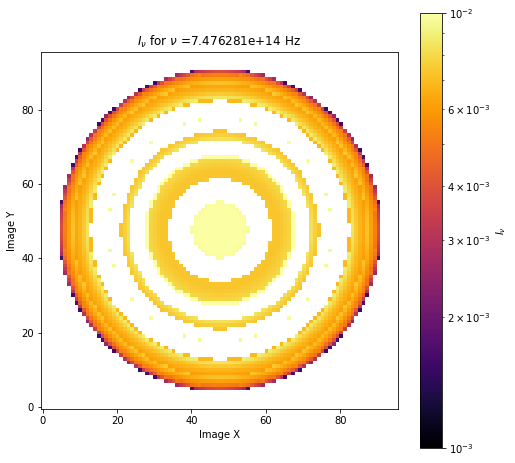

In [47]:
fig,ax = plt.subplots(figsize=(8,8))
frequencies = np.array(file['frequency'][5])
plt.imshow(file['I_nu'][5],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-3,vmax=1e-2))
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title("$I_\\nu$ for $\\nu$ ={freq:e} Hz".format(freq=frequencies))
#plt.title('$I_\\nu$ w middle for i=90')

#plt.savefig('../plots/cbdisk/ff_tabular/i45_cbdisk_Inu.png', bbox_inches='tight', dpi=300)
plt.show()

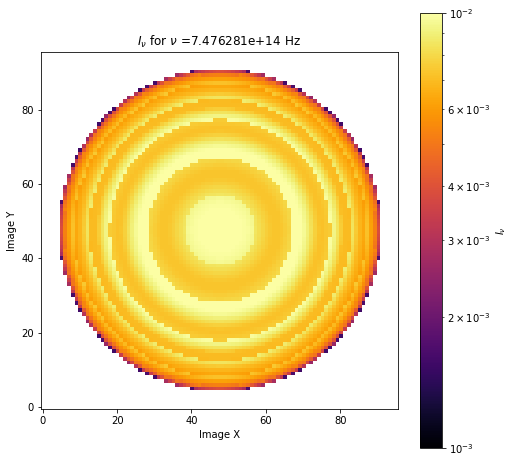

In [44]:
fig,ax = plt.subplots(figsize=(8,8))
frequencies = np.array(file2['frequency'][5])
plt.imshow(file2['I_nu'][5],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-3,vmax=1e-2))
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title("$I_\\nu$ for $\\nu$ ={freq:e} Hz".format(freq=frequencies))
#plt.title('$I_\\nu$ w middle for i=90')

#plt.savefig('../plots/cbdisk/ff_tabular/i45_cbdisk_Inu.png', bbox_inches='tight', dpi=300)
plt.show()

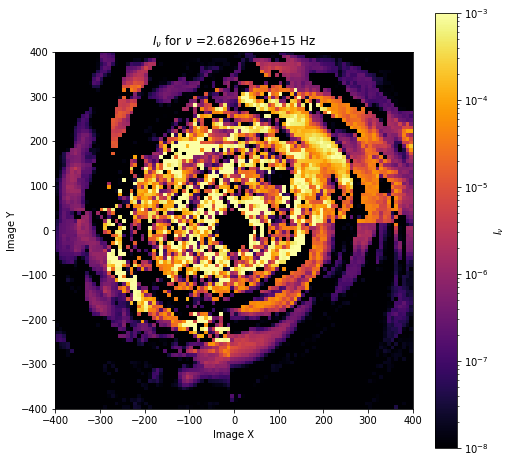

In [12]:
fig,ax = plt.subplots(figsize=(8,8))
frequencies = np.array(file2['frequency'][5])
plt.imshow(file2['I_nu'][5],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-8,vmax=1e-3),extent=[-400,400,-400,400])
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title("$I_\\nu$ for $\\nu$ ={freq:e} Hz".format(freq=frequencies))
#plt.title('$I_\\nu$ w middle for i=90')

#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

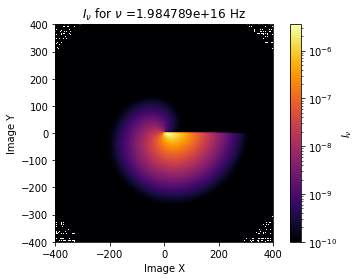

In [16]:
frequencies = np.array(file['frequency'][11])
plt.imshow(file['I_nu'][11],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-10),extent=[-400,400,-400,400])
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title("$I_\\nu$ for $\\nu$ ={freq:e} Hz".format(freq=frequencies))
#plt.title('$I_\\nu$ w middle for i=90')

#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

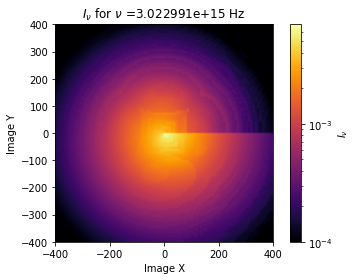

In [12]:
frequencies = np.array(file['frequency'][8])
plt.imshow(file['I_nu'][8],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-4),extent=[-400,400,-400,400])
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title("$I_\\nu$ for $\\nu$ ={freq:e} Hz".format(freq=frequencies))
#plt.title('$I_\\nu$ w middle for i=90')

#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

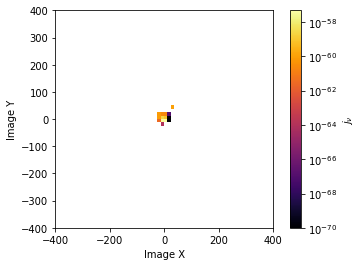

In [21]:
frequencies = np.array(file['frequency'][18])
plt.imshow(file['emission'][18],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-70),extent=[-400,400,-400,400])
plt.colorbar(label="$j_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
#plt.title('$I_\\nu$ w middle for i=90')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

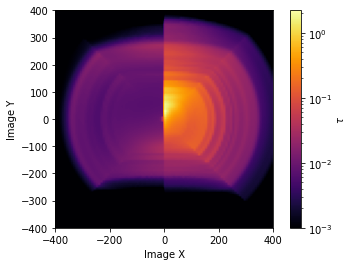

In [25]:
frequencies = np.array(file['frequency'][18])
plt.imshow(file['tau'][18],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-3),extent=[-400,400,-400,400])
plt.colorbar(label="$\\tau$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
#plt.title('$I_\\nu$ w middle for i=90')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

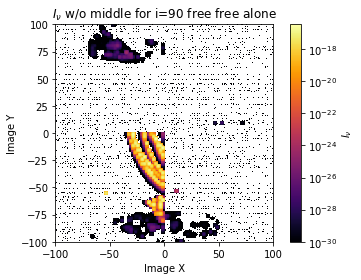

In [25]:
frequencies = np.array(file2['frequency'][18])
plt.imshow(file2['I_nu'][18],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-30),extent=[-100,100,-100,100])
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title('$I_\\nu$ w/o middle for i=90 free free alone')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

In [14]:
jnu = pd.read_csv('../debugOutput/scattering_comparison.csv',header=None,names=['rho','T','nu','j_nu','scattering'])

In [15]:
jnu

,rho,T,nu,j_nu,scattering
0,1.584320e-10,50361,2.000000e+14,1.606420e-15,2.023740e-25
1,1.584320e-10,50361,2.603520e+14,1.606420e-15,2.023740e-25
2,1.584320e-10,50361,3.389160e+14,1.088360e-15,1.371100e-25
3,1.584320e-10,50361,4.411880e+14,3.183830e-15,4.010940e-25
4,1.584320e-10,50361,5.743210e+14,4.929430e-15,6.210030e-25
...,...,...,...,...,...
195,1.566430e-10,50361,1.044710e+16,1.871100e-13,2.330570e-23
196,1.566430e-10,50361,1.359970e+16,8.069070e-14,1.005050e-23
197,1.566430e-10,50361,1.770350e+16,2.020290e-14,2.516400e-24
198,1.566430e-10,50361,2.304570e+16,6.058420e-15,7.546150e-25


In [16]:
frequencies = np.array(file['frequency'])

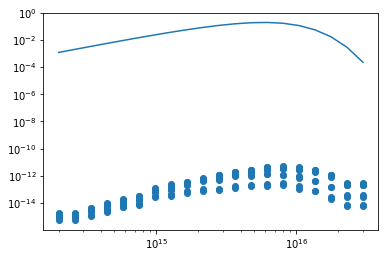

In [17]:
bnu = 2*h*frequencies**3/c**2/(np.exp(h*frequencies/(kB*1e5))-1)
plt.plot(frequencies,bnu,label='Blackbody at 10^5 K')
plt.scatter(jnu['nu'],jnu['j_nu'],label='Scattering Emissivity')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
plt.plot(jnu['nu'],)

In [14]:
frequencies = np.array(file['frequency'][18])
plt.imshow(file['emission'][18],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-70),extent=[-100,100,-100,100])
plt.colorbar(label="$j_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title('$j_\\nu$ w middle for i=89')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

KeyError: 'emission is not a file in the archive'

In [15]:
frequencies = np.array(file2['frequency'][18])
plt.imshow(file2['emission'][18],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-70),extent=[-100,100,-100,100])
plt.colorbar(label="$j_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title('$j_\\nu$ w/o middle for i=89')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

KeyError: 'emission is not a file in the archive'

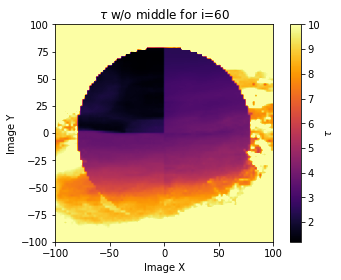

In [21]:
frequencies = np.array(file2['frequency'][18])
plt.imshow(file2['tau'][18],cmap='inferno',origin='lower',vmax=10,extent=[-100,100,-100,100])
plt.colorbar(label="$\\tau$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title('$\\tau$ w/o middle for i=60')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

In [31]:
np.argwhere(file['I_nu'][11]!=0).shape

(4776, 2)

In [34]:
4776/(96*96)

0.5182291666666666

In [2]:
default_args = {}
default_args['figsize'] = (4,4)
default_args['filename_data'] = '../output/example_free_free_tde.npz'
default_args['filename_plot'] = None
default_args['stokes_q'] = False
default_args['stokes_u'] = False
default_args['stokes_v'] = False
default_args['name'] = None
default_args['frequency_num'] = None
default_args['refinement_level'] = False
default_args['width'] = None
default_args['mass'] = None
default_args['distance'] = None
default_args['axes'] = None
default_args['max_level'] = None
default_args['vmin'] = None
default_args['vmax'] = None
default_args['cmap'] = None
default_args['notex'] = False
default_args['fontsize'] = None

In [3]:
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["figure.dpi"] = 100

In [50]:
temp=(100*G*Mbh/c**2)*u.cgs.cm
print(temp)
print(temp.to(u.pc))

44298751141503.734 cm
1.4356247524763523e-05 pc


In [73]:
v0=0.001
mu=0.5
rho0=1.543e-3
P0 = rho0*v0*v0*c*c
print(P0)
print(mu*mp*v0*v0*c*c/kB)

1386779240790.9097
5444097.725001525


In [9]:
(2.998e+07)/c

0.00100002515740406

In [4]:
((288*me*((4.8e-10)**2)*((0.8853)**3)*((4*np.pi)**(4/3))*((5.29e-9)**3)/((3*1.66e-24)**(4/3)))**(5/2))/(15*hbar*hbar*hbar*(np.pi**2)*me)

4.200804832009859e+16

In [7]:
9.478e9/1.158e11

0.08184801381692573

In [19]:
(c*3.335e-08)**2*mu*mp

1.0031875129470097e-18

In [20]:
6.553e6*kB

9.047392897e-10

In [150]:
def j_I(T,nu,ne,ni):
    #1/kBT is like 4.39e13
    #the exponent keeps going to 0
    return (16*np.exp(6)/(3*me*c**3))*np.sqrt(1/me)*np.sqrt(2*np.pi/(3*kB*T))*(ne*ni)*np.exp(-h*nu/(kB*T))*(nu**(-2))

In [151]:
def alpha_I(T,nu,ne,ni):
    return (4*np.exp(6)/(3*me*c*h))*np.sqrt(1/me)*np.sqrt(2*np.pi/(3*kB*T))*ne*ni*(1-np.exp(-h*nu/(kB*T)))*(nu**(-2))

In [178]:
#assuming optically thick
def I_nu(T,nu,ne,ni):
    return (nu**3)*j_I(T,nu,ne,ni)/alpha_I(T,nu,ne,ni)
def nuFnu(T,nu,ne,ni,dist,mass):
    gg_msun = 1.32712440018e26
    rg = gg_msun * mass / c ** 2
    return nu*np.nanmean(I_nu(T,nu,ne,ni))*4*np.pi*((dist*rg)**2)

In [179]:
arguments = {'data_file': '../data/input.cbdisk.out1.01637_float32.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)

(768, 512)


In [81]:
arguments = {'data_file': '../data/input.cbdisk.out1.01637_float32.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)

(768, 512)


In [180]:
rho0=1.543e-3
kT = mu*mp*(v0**2)*(c**2)*(press/rho)
T = kT/kB

In [12]:
hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc45.npz')

In [17]:
hf = np.load('../output/xiaoshan_r1200_w400_pinhole_tde1020_inc90_opacTable.npz')

In [34]:
np.array(hf['frequency'][9])

array(2.35427991e+16)

In [35]:
np.array(hf['frequency'][18])

array(1.84754463e+18)

In [37]:
spm = hf['I_nu'][18]


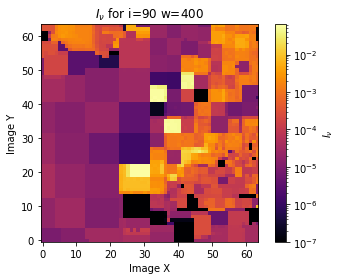

In [18]:
frequencies = np.array(hf['frequency'][18])
plt.imshow(hf['I_nu'][18],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-7))
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title('$I_\\nu$ for i=90 w=400')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

In [38]:
hf = np.load('../output/r1200_pinhole_tde1335_inc15.npz')

In [39]:
sks = hf['I_nu'][18]

In [41]:
spm-sks

array([[ 0.00000000e+000,  0.00000000e+000,  1.11476513e-255, ...,
         3.62395728e-014,  4.22478719e-131,  3.98328934e-141],
       [ 0.00000000e+000,  1.15059613e-263,  1.74604128e-253, ...,
         4.49908349e-126,  1.90221611e-131,  3.86657158e-138],
       [ 0.00000000e+000,  3.22271114e-259,  1.70103291e-243, ...,
         3.91902322e-127,  1.52221531e-020,  5.37528876e-144],
       ...,
       [ 1.85053087e-253,  2.59886665e-240,  5.96783904e-228, ...,
        -9.88159379e-229,  5.02155777e-244,  0.00000000e+000],
       [ 1.68032345e-215,  9.62511429e-245,  2.53397644e-231, ...,
        -1.98893489e-228, -5.90257658e-229,  0.00000000e+000],
       [ 3.43458227e-258,  1.51815507e-245,  3.30262222e-234, ...,
        -2.50119666e-228, -1.89940735e-228,  0.00000000e+000]])

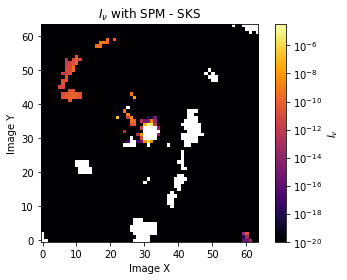

In [45]:
frequencies = np.array(hf['frequency'][18])
plt.imshow(spm-sks,cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e-20))
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title('$I_\\nu$ with SPM - SKS')
plt.savefig('../plots/tde_I_nu_SPM_minus_SKS.png', bbox_inches='tight', dpi=300)
plt.show()

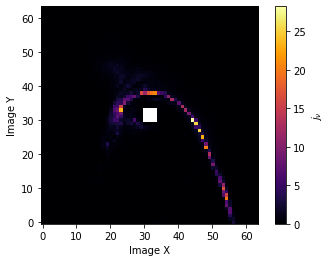

In [45]:
frequencies = np.array(hf['frequency'])
plt.imshow(hf['I_nu'],cmap='inferno',origin='lower')
plt.colorbar(label="$j_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

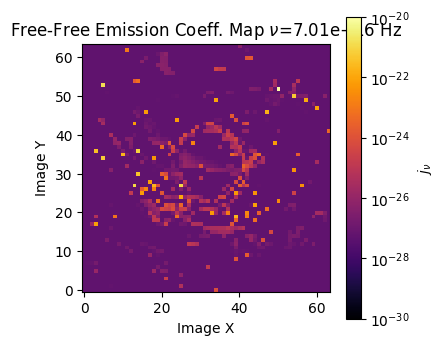

In [ ]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['emission'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-60
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-30))
plt.colorbar(label="$j_\\nu$")
plt.title('Free-Free Emission Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

In [15]:
hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc45_opacitytable.npz')

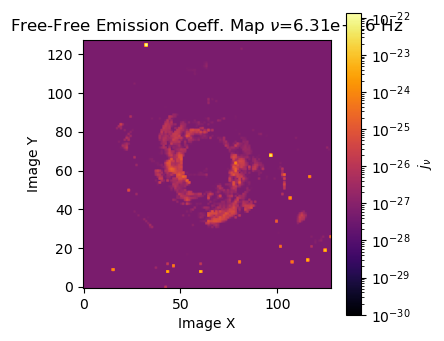

In [16]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['emission'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-60
i[i<minVal]=minVal

plt.imshow(i*(2.39e16)**2,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-30))
plt.colorbar(label="$j_\\nu$")
plt.title('Free-Free Emission Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

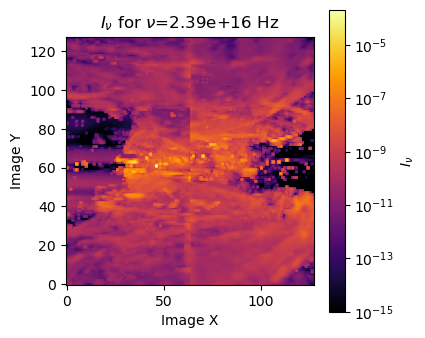

In [18]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-15
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('$I_\\nu$ for $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

the above image looks really ugly. I think that I should zoom out even more and also I should try to check different phi values/inc values. in particular it seems like the boundary out in front is weird.

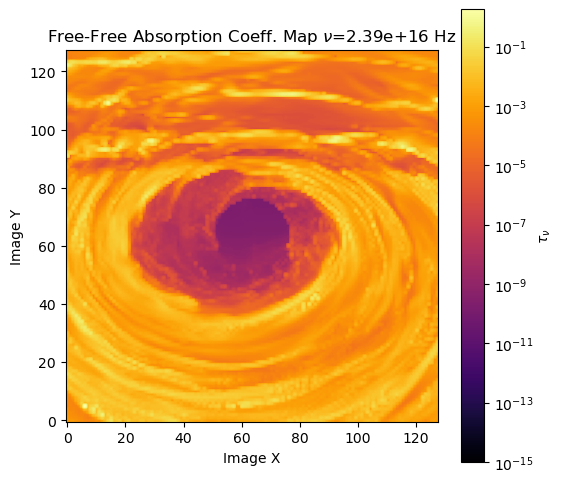

In [11]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['tau'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-15
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$\\tau_\\nu$")
plt.title('Free-Free Absorption Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

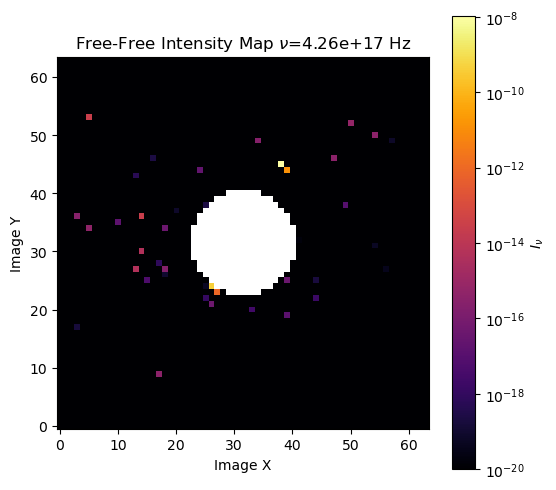

In [49]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

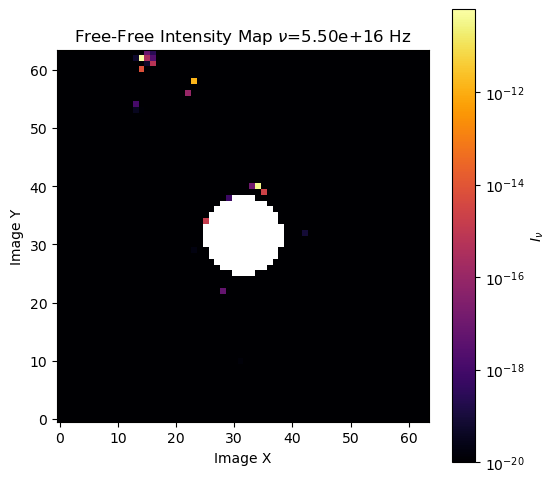

In [22]:
frequencies = np.array(hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

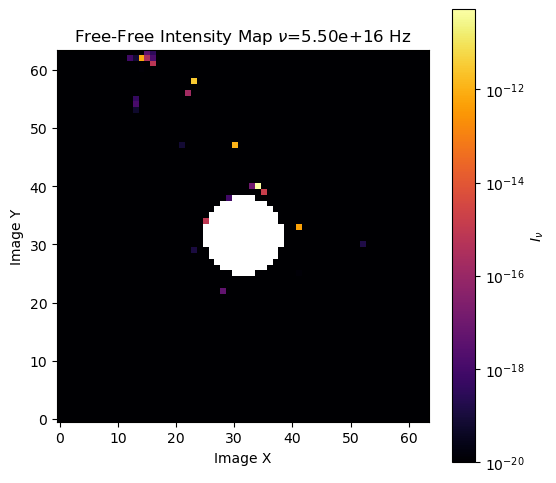

In [15]:
frequencies = np.array(r2hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(r2hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

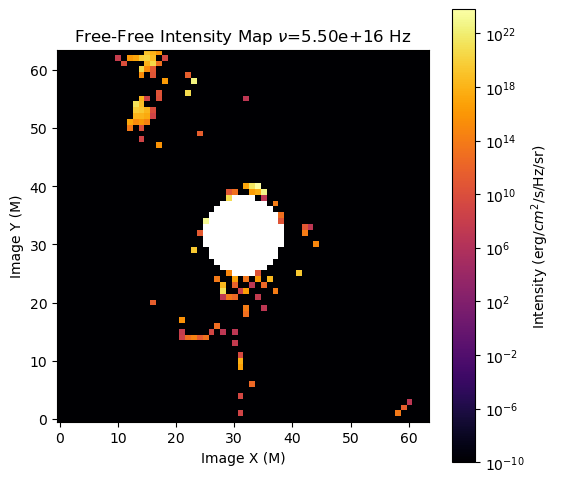

In [38]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

In [48]:
freq = len(frequencies)-3
print(np.nanmean(i))
print(np.nanmedian(i))

4.245919609251542e+21
1e-10


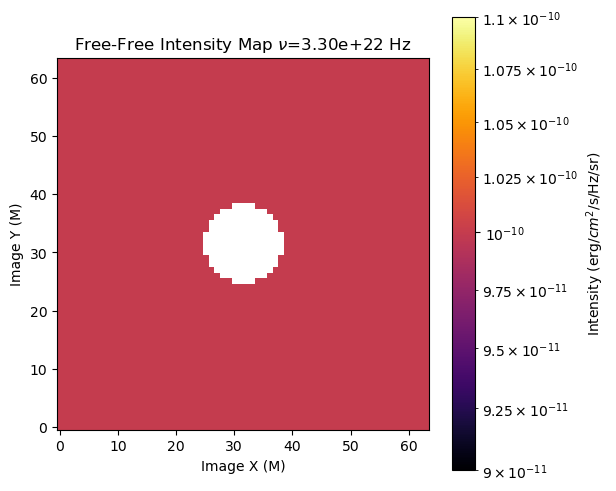

In [ ]:
freq = len(frequencies)-2
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

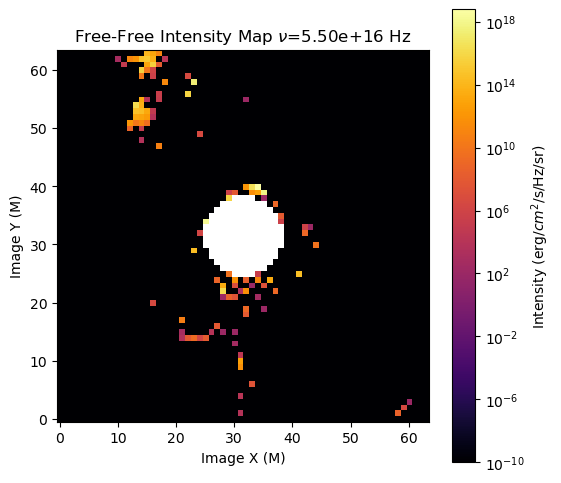

In [33]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(temp['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

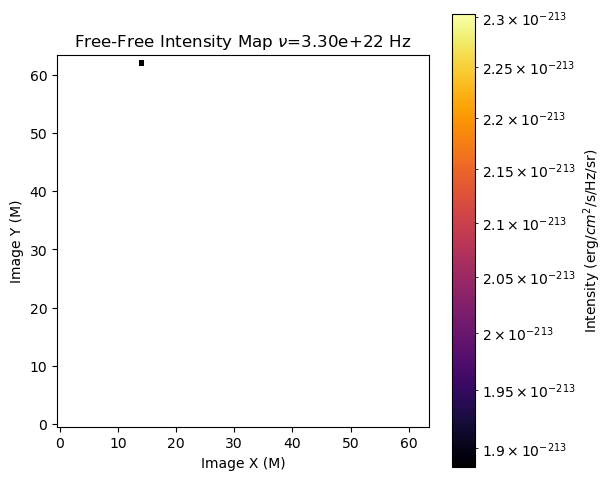

In [ ]:
for freq in range(len(frequencies)-1):
    plt.clf()
    plt.imshow(hf['I_nu'][freq],cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm())
    plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
    plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
    plt.xlabel('Image X (M)')
    plt.ylabel('Image Y (M)')
    #plt.show()
    plt.savefig('../plots/free_free_image_{0:.2e}Hz.png'.format(frequencies[freq]))

/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:446: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:453: UserWarning: Warning: converting a masked element to nan.
  a_min = np.float64(newmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:458: UserWarning: Warning: converting a masked element to nan.
  a_max = np.float64(newmax)


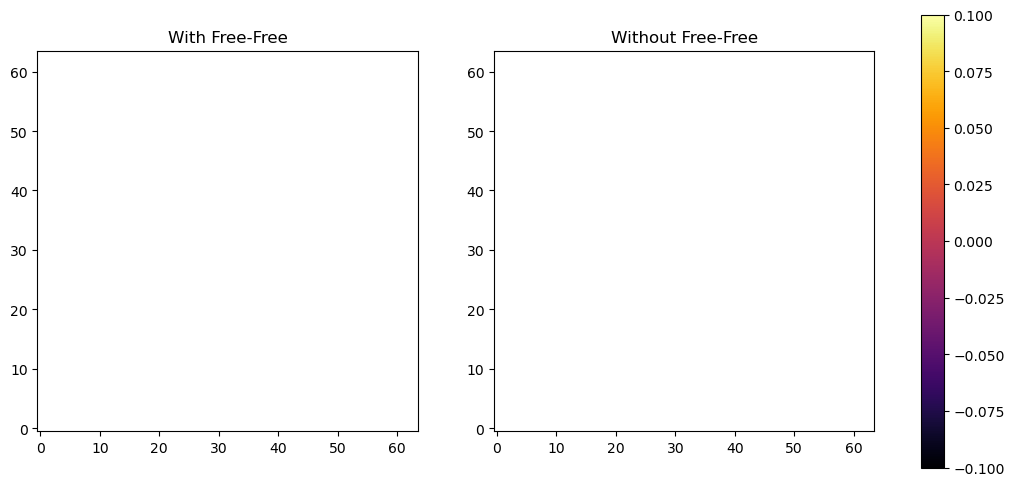

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(hf['I_nu'][15], cmap='inferno', origin='lower',vmax=1e15)
ax[1].imshow(hs['I_nu'][0], cmap='inferno', origin='lower',vmax=1e-3)
ax[0].set_title('With Free-Free')
ax[1].set_title('Without Free-Free')
plt.colorbar(ax[1].images[0], ax=ax, fraction=0.05)
plt.show()

In [24]:
free['I_nu'][32,32]

8.411915668450402e-08

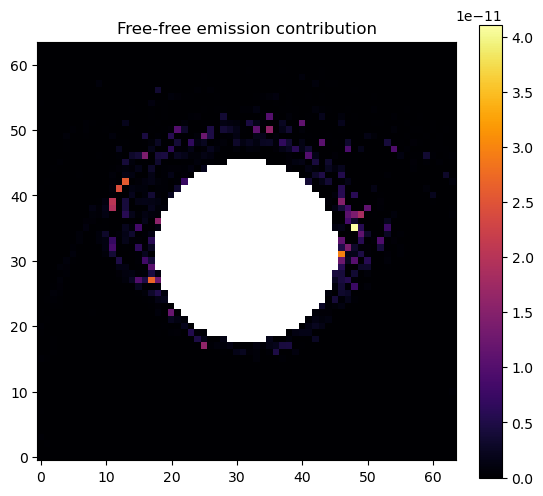

In [8]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['emission']-hs['emission'], cmap='inferno', origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Free-free emission contribution')
plt.show()

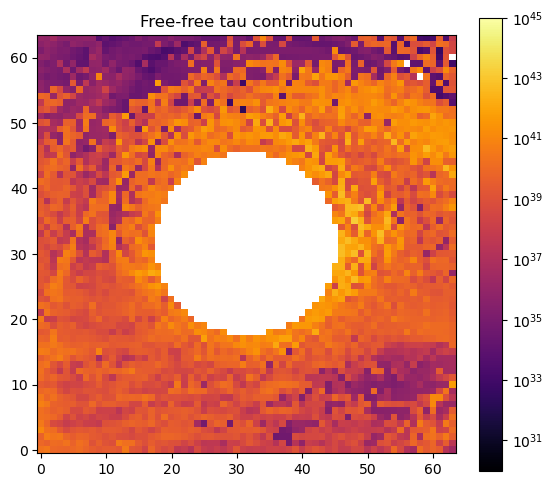

In [9]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['tau']-hs['tau'], cmap='inferno', origin='lower',norm=LogNorm(vmin=1e30, vmax=1e45))
plt.colorbar(fraction=0.05)
plt.title('Free-free tau contribution')
plt.show()

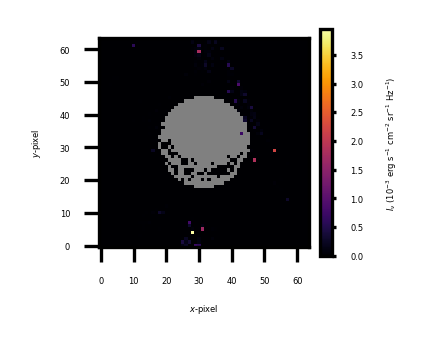

In [6]:
default_args['fontsize'] = (2)
default_args['figsize'] = (1,1)

fig,ax = utils.plot_data(**default_args)
#ax.margins(x=0,y=0)
plt.show()

# make spectrum

In [14]:
tabOpacity = np.load('../output/r1600_w800_pinhole_cbdisk_inc90_opacitytable.npz')
free = np.load('../output/r1600_w800_pinhole_cbdisk_inc90.npz')

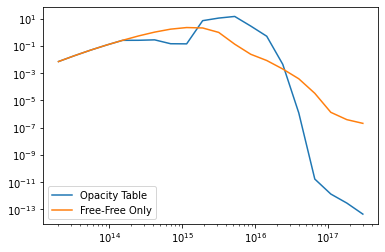

In [16]:
plt.plot(tabOpacity['frequency'],np.sum(tabOpacity['I_nu'],axis=(1,2)),label='Opacity Table')
plt.plot(free['frequency'],np.sum(free['I_nu'],axis=(1,2)),label='Free-Free Only')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

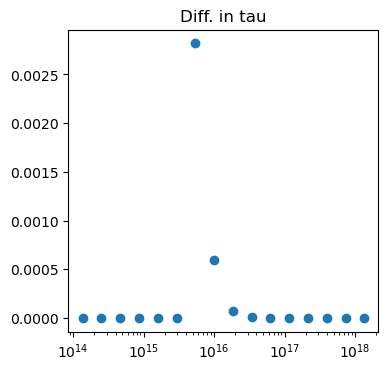

In [30]:
plt.scatter(tabOpacity['frequency'],np.sum(tabOpacity['tau'],axis=(1,2))-np.sum(free['tau'],axis=(1,2)))
plt.title('Diff. in tau')
plt.xscale('log')
plt.show()

# GRFP plots

In [4]:
2.68/1.88

1.4255319148936172

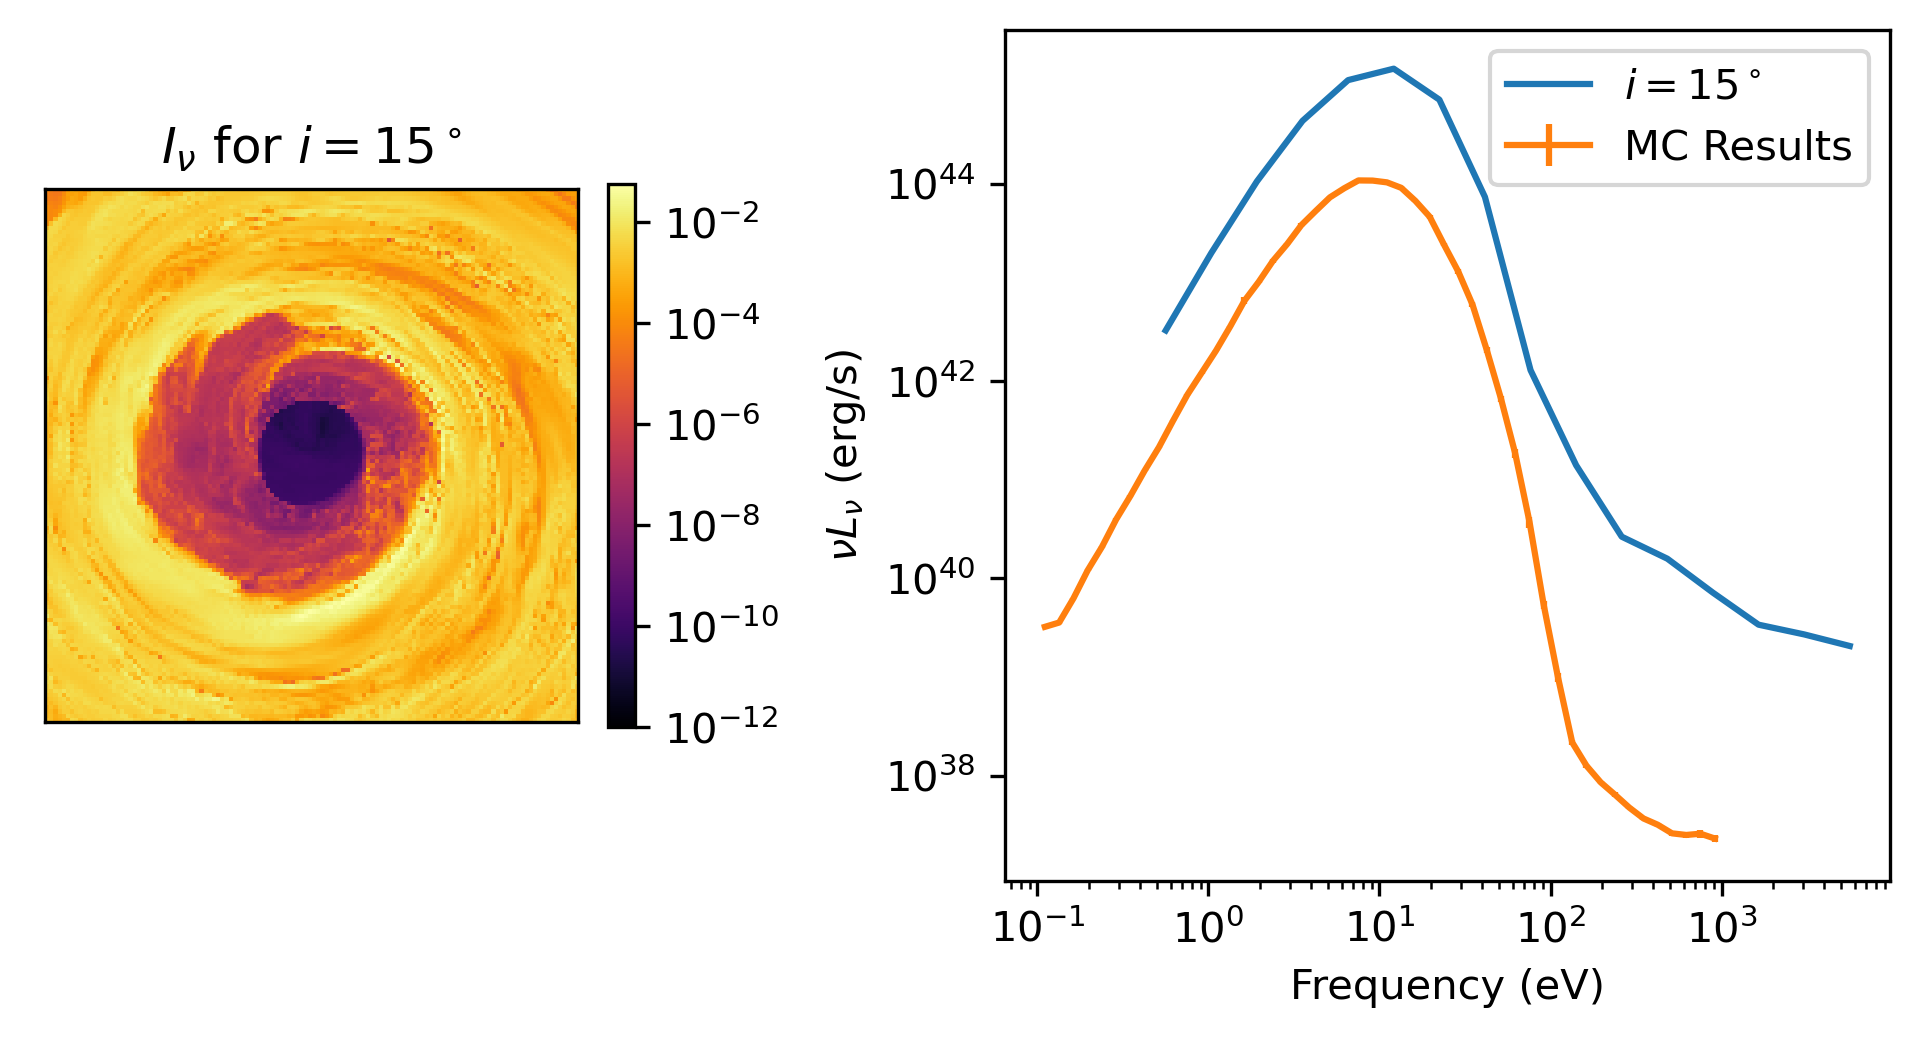

In [15]:
#2.68 width vs 1.88 height
h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc15.npz')
width = 3.25
height = 1.78
scale = 2
fig,axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [2, 3]}, figsize=(width*scale,height*scale),dpi=300)
minVal = 1e-12

im = axs[0].imshow(hf['I_nu'][4],cmap='inferno',origin='lower', norm=colors.LogNorm(vmin=minVal), extent=[-800,800,-800,800])
fig.colorbar(im, ax=axs[0], fraction=0.046)
axs[0].set_title('$I_\\nu$ for $i = 15^\\circ$')
axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)

argumentDict = {}
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc15.npz'
argumentDict['distance'] = 1600
argumentDict['mass'] = 2e7
argumentDict['frequency_num'] = 16
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 800.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)
flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

axs[1].plot(freqs1*h_ev,freqs1*flux*eV,label='$i = 15^\\circ$')
shaneResults = np.loadtxt('../cbdisk_spectrum.txt')
axs[1].errorbar(shaneResults[:,0]*1e3,shaneResults[:,1],yerr=shaneResults[:,2],label='MC Results')
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Frequency (eV)')
axs[1].set_ylabel('$\\nu L_\\nu$ (erg/s)')
axs[1].set_aspect('auto')
plt.tight_layout()
plt.show()

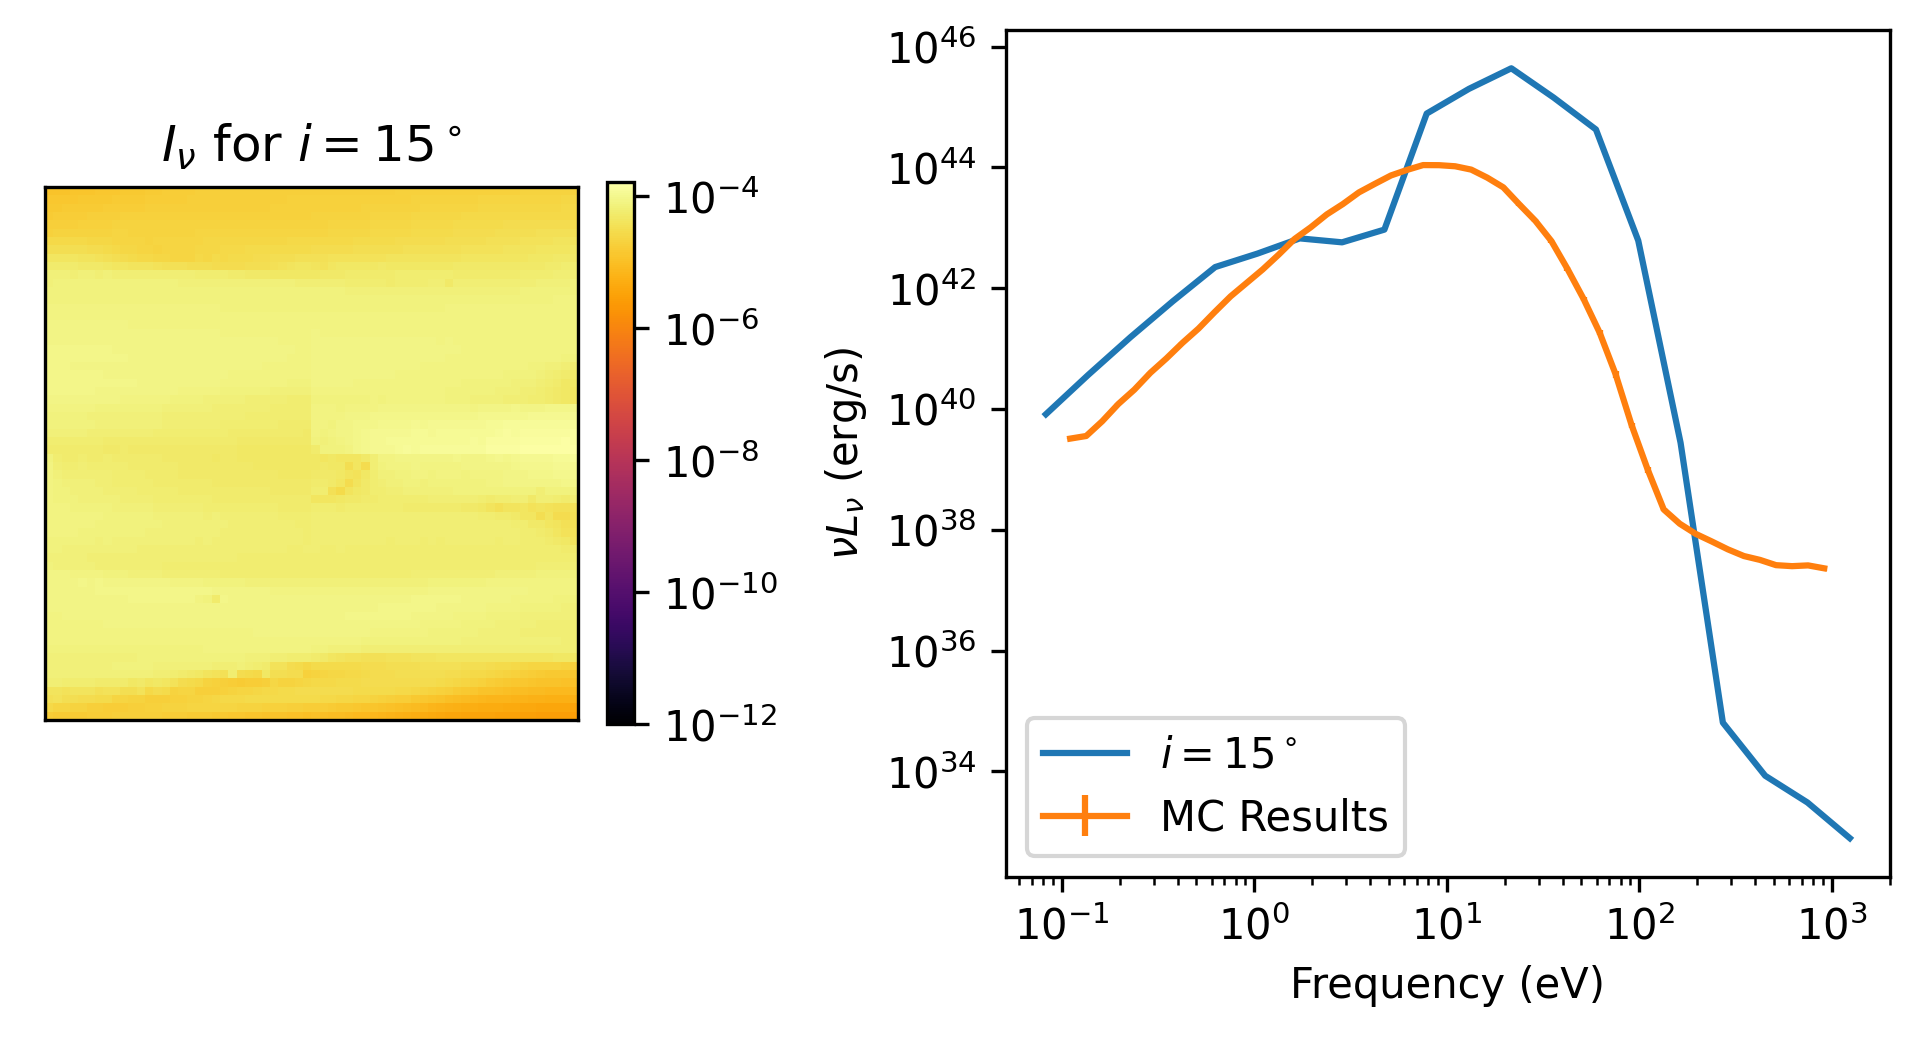

In [ ]:
#2.68 width vs 1.88 height
h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc15.npz')
width = 3.25
height = 1.78
scale = 2
fig,axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [2, 3]}, figsize=(width*scale,height*scale),dpi=300)
minVal = 1e-12

im = axs[0].imshow(hf['I_nu'][4],cmap='inferno',origin='lower', norm=colors.LogNorm(vmin=minVal), extent=[-800,800,-800,800])
fig.colorbar(im, ax=axs[0], fraction=0.046)
axs[0].set_title('$I_\\nu$ for $i = 15^\\circ$')
axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)

argumentDict = {}
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc15.npz'
argumentDict['distance'] = 1600
argumentDict['mass'] = 2e7
argumentDict['frequency_num'] = 16
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 800.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)
flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

axs[1].plot(freqs1*h_ev,freqs1*flux*eV,label='$i = 15^\\circ$')
shaneResults = np.loadtxt('../cbdisk_spectrum.txt')
axs[1].errorbar(shaneResults[:,0]*1e3,shaneResults[:,1],yerr=shaneResults[:,2],label='MC Results')
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Frequency (eV)')
axs[1].set_ylabel('$\\nu L_\\nu$ (erg/s)')
axs[1].set_aspect('auto')
plt.tight_layout()
plt.show()

In [6]:
import matplotlib.font_manager
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [10]:
from matplotlib import RcParams
import matplotlib.pyplot as plt

latex_style_times = RcParams({'font.family': 'serif',
               'font.serif': ['Times'],
               'text.usetex': True,
               })

plt.style.use(latex_style_times)

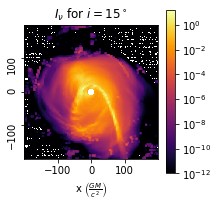

In [34]:

fig,ax = plt.subplots(1,1,figsize=(3,3))
minVal = 1e-12
from mpl_toolkits.axes_grid1 import make_axes_locatable

hf = np.load('../output/r1200_pinhole_tde1335_inc15.npz')
im = ax.imshow(hf['I_nu'][10],cmap='inferno',origin='lower', norm=colors.LogNorm(vmin=minVal), extent=[-200,200,-200,200])

fig.colorbar(im)
ax.set_title('$I_\\nu$ for $i = 15^\\circ$')
ax.set_xticks([-100,0,100])
ax.set_yticks([-100,0,100])
ax.tick_params("y",rotation=90)
ax.set_xlabel('x $\\left(\\frac{GM}{c^2}\\right)$')
#circ = Circle((0, 0), 140, color='white', fill=True,alpha=0.5)
#ax.add_patch(circ)
fig.savefig('../plots/tde1335_inc15_image.png', bbox_inches='tight', dpi=300)
plt.show()


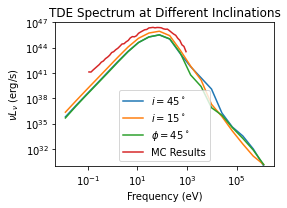

In [48]:

h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

fig,ax = plt.subplots(1,1,figsize=(4,3))
argumentDict = {}
argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc45.npz'
argumentDict['distance'] = 1200
argumentDict['mass'] = 3e6
argumentDict['frequency_num'] = 20
argumentDict['luminosity'] = True
argumentDict['inclination'] = 45.0
argumentDict['width'] = 400.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)


flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

ax.plot(freqs1*h_ev,freqs1*flux*eV,label='$i = 45^\\circ$')

argumentDict['inclination'] = 15.0
argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15.npz'
flux2, freqs2 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs2*h_ev,freqs2*flux*eV,label='$i = 15^\\circ$')


argumentDict['inclination'] = 45.0
argumentDict['filename_data'] = '../output/r800_pinhole_tde1335_phi45.npz'
flux3, freqs3 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux3*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs3*h_ev,freqs3*flux*eV,label='$\\phi = 45^\\circ$')

shaneResults = np.loadtxt('../spec.txt')
ax.plot(shaneResults[:,0]*h_ev,shaneResults[:,1]*1e3,label='MC Results')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e30,1e47)
ax.set_xlabel('Frequency (eV)')
ax.set_ylabel('$\\nu L_\\nu$ (erg/s)')
ax.set_title('TDE Spectrum at Different Inclinations')
plt.tight_layout()

fig.savefig('../plots/tde1335_spectrum.png', bbox_inches='tight', dpi=300)
ax.set_aspect('auto')

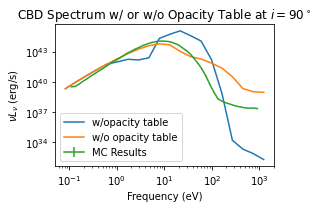

In [18]:

h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

fig,ax = plt.subplots(1,1,figsize=(4,3))
argumentDict = {}
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc90_opacitytable.npz'
argumentDict['distance'] = 1600
argumentDict['mass'] = 2e7
argumentDict['frequency_num'] = 16
argumentDict['luminosity'] = True
argumentDict['inclination'] = 90.0
argumentDict['width'] = 800.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)


flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

ax.plot(freqs1*h_ev,freqs1*flux*eV,label='w/opacity table')

#argumentDict['inclination'] = 45.0
#argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc45.npz'
#flux2, freqs2 = sp.get_flux(**argumentDict)
#convert flux to luminosity
#distance_cm = (argumentDict['distance']*rg)
#thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
#flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
#ax.plot(freqs2*h_ev,freqs2*flux*eV,label='$i = 45^\\circ$')


argumentDict['inclination'] = 90.0
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc90.npz'
flux3, freqs3 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux3*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs3*h_ev,freqs3*flux*eV,label='w/o opacity table')

shaneResults = np.loadtxt('../cbdisk_spectrum.txt')
ax.errorbar(shaneResults[:,0]*1e3,shaneResults[:,1],yerr=shaneResults[:,2],label='MC Results')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency (eV)')
ax.set_ylabel('$\\nu L_\\nu$ (erg/s)')
ax.set_title('CBD Spectrum w/ or w/o Opacity Table at $i = 90^\\circ$')
plt.tight_layout()

fig.savefig('../plots/cbdisk_spectrum_opacityTable.png', bbox_inches='tight', dpi=300)
ax.set_aspect('auto')

## spectrum

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
import spectrum as sp
from matplotlib.patches import Circle
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
hbar=h/(2*np.pi)
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
me=cons.m_e.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2
e= 4.80320425e-10


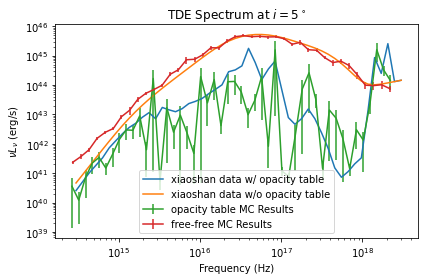

In [4]:

h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26
distance_cm = G*1200 * Msun * 1e6 / c**2
disk_radii_cm = G*200 * Msun * 1e6 / c**2

fig,ax = plt.subplots(1,1,figsize=(6,4))
argumentDict = {}
argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15_opacitytable.npz'
argumentDict['distance'] = 1200
argumentDict['mass'] = 3e6
argumentDict['frequency_num'] = 20
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 200.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)


#flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
#distance_cm = (argumentDict['distance']*rg)
#thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
#flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
#ax.plot(freqs1,freqs1*flux*eV,label='w/ opacity table')

argumentDict['filename_data'] = '../output/xiaoshan_r1200_pinhole_tde1_inc5_opacityTable.npz'
argumentDict['inclination'] = 5.0
#argumentDict['distance'] = 800
flux2, freqs2 = sp.get_flux(**argumentDict)
#thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = flux2*((np.arctan(0.5*argumentDict['width']/argumentDict['distance']))**2)*4*np.pi*distance_cm**2
#flux = (flux2*2*np.cos(np.radians(argumentDict['inclination']))*(np.pi*disk_radii_cm)**2)
ax.plot(freqs2,freqs2*flux,label='xiaoshan data w/ opacity table')

argumentDict['filename_data'] = '../output/xiaoshan_r1200_pinhole_tde1_inc5.npz'
#argumentDict['inclination'] = 45.0
#argumentDict['distance'] = 1200
flux2, freqs2 = sp.get_flux(**argumentDict)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
#flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
#flux = (flux2*2*np.cos(np.radians(argumentDict['inclination']))*(np.pi*disk_radii_cm)**2)
flux = flux2*((np.arctan(0.5*argumentDict['width']/argumentDict['distance']))**2)*4*np.pi*distance_cm**2
ax.plot(freqs2,freqs2*flux,label='xiaoshan data w/o opacity table')


#argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15.npz'
#argumentDict['distance'] = 1200
#flux2, freqs2 = sp.get_flux(**argumentDict)
#thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
#flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
#ax.plot(freqs2,freqs2*flux*eV,label='w/o opacity table')

shaneResults = np.loadtxt('../spectrum_xiaoshan_opacitytable.txt')
#ax.plot(shaneResults[:,0],shaneResults[:,1]*1e3,label='MC Results')
ax.errorbar(shaneResults[:,0]*1e3/h_ev,shaneResults[:,1],yerr=shaneResults[:,2],label='opacity table MC Results')

shaneResults = np.loadtxt('../spectrum_musum.txt')
#ax.plot(shaneResults[:,0],shaneResults[:,1]*1e3,label='MC Results')
ax.errorbar(shaneResults[:,0]*1e3/h_ev,shaneResults[:,1],yerr=shaneResults[:,2],label='free-free MC Results')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('$\\nu L_\\nu$ (erg/s)')
ax.set_title('TDE Spectrum at $i = 5^\\circ$')
#ax.set_ylim(1e30,1e49)
plt.tight_layout()
#plt.savefig('../plots/tde1335_spectrum_opacitytable_test.png', bbox_inches='tight', dpi=300)
plt.show()

In [27]:
print(flux[25]*frequency[25]/shaneResults[21,1])

5.911868923303879


In [4]:
2*np.cos(np.radians(argumentDict['inclination']))*(np.pi*disk_radii_cm)**2

2.7440650181843224e+29

In [5]:
file = np.load('../output/xiaoshan_r1200_pinhole_tde1_inc15_opacityTable.npz')
print(list(file.keys()))

['mass_msun', 'width', 'frequency', 'adaptive_num_levels', 'I_nu', 'emission', 'tau']


In [15]:
frequency = file['frequency']

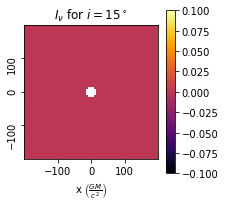

In [6]:

fig,ax = plt.subplots(1,1,figsize=(3,3))
minVal = 1e-12
from mpl_toolkits.axes_grid1 import make_axes_locatable

im = ax.imshow(file['I_nu'][10],cmap='inferno',origin='lower', extent=[-200,200,-200,200])

fig.colorbar(im)
ax.set_title('$I_\\nu$ for $i = 15^\\circ$')
ax.set_xticks([-100,0,100])
ax.set_yticks([-100,0,100])
ax.tick_params("y",rotation=90)
ax.set_xlabel('x $\\left(\\frac{GM}{c^2}\\right)$')
#circ = Circle((0, 0), 140, color='white', fill=True,alpha=0.5)
#ax.add_patch(circ)
plt.show()


In [ ]:
1e-3*1.602176634e-9/h
#2.417989 e 14

241798924208491.84

In [20]:
tableValues = np.loadtxt('../data/opacity_table_copy.txt')
print(tableValues.shape)

(1104, 100)


In [21]:
tableValues

array([[8.1921e+01, 8.1921e+01, 8.1921e+01, ..., 1.7685e+00, 2.0712e+00,
        2.4621e+00],
       [9.0404e+00, 9.0404e+00, 9.0404e+00, ..., 3.4320e+00, 3.9876e+00,
        4.6195e+00],
       [5.0999e-01, 5.0999e-01, 5.0999e-01, ..., 6.7127e+01, 7.0287e+01,
        7.4368e+01],
       ...,
       [1.6541e-13, 1.6541e-13, 1.6541e-13, ..., 8.5838e-10, 1.1086e-09,
        1.4319e-09],
       [9.2493e-14, 9.2493e-14, 9.2493e-14, ..., 6.8130e-10, 8.7993e-10,
        1.1365e-09],
       [5.8976e-14, 5.8976e-14, 5.8976e-14, ..., 5.6172e-10, 7.2549e-10,
        9.3700e-10]])

In [22]:
tableValues=tableValues.reshape((16,69,100))
print(tableValues)

[[[8.1921e+01 8.1921e+01 8.1921e+01 ... 1.7685e+00 2.0712e+00 2.4621e+00]
  [9.0404e+00 9.0404e+00 9.0404e+00 ... 3.4320e+00 3.9876e+00 4.6195e+00]
  [5.0999e-01 5.0999e-01 5.0999e-01 ... 6.7127e+01 7.0287e+01 7.4368e+01]
  ...
  [1.6541e-13 1.6541e-13 1.6541e-13 ... 2.0265e-01 2.6173e-01 3.3803e-01]
  [9.2493e-14 9.2493e-14 9.2493e-14 ... 1.3185e-01 1.7030e-01 2.1995e-01]
  [5.8976e-14 5.8976e-14 5.8976e-14 ... 9.4484e-02 1.2203e-01 1.5761e-01]]

 [[8.1921e+01 8.1921e+01 8.1921e+01 ... 1.8512e+01 2.1687e+01 2.5787e+01]
  [9.0404e+00 9.0404e+00 9.0404e+00 ... 1.6196e+01 1.8021e+01 2.0083e+01]
  [5.0999e-01 5.0999e-01 5.0999e-01 ... 3.1534e+02 3.2206e+02 3.3075e+02]
  ...
  [1.6541e-13 1.6541e-13 1.6541e-13 ... 6.4077e-02 8.2759e-02 1.0689e-01]
  [9.2493e-14 9.2493e-14 9.2493e-14 ... 4.1694e-02 5.3849e-02 6.9549e-02]
  [5.8976e-14 5.8976e-14 5.8976e-14 ... 2.9877e-02 3.8588e-02 4.9838e-02]]

 [[8.1921e+01 8.1921e+01 8.1921e+01 ... 1.4485e+03 1.4998e+03 1.5660e+03]
  [9.0404e+00 9.0404e+

In [23]:
temperatures = [5.0000E-04,
6.0000E-04,
8.0000E-04,
1.0000E-03,
1.2500E-03,
1.5000E-03,
2.0000E-03,
2.5000E-03,
3.0000E-03,
3.5000E-03,
4.0000E-03,
5.0000E-03,
6.0000E-03,
7.0000E-03,
8.0000E-03,
9.0000E-03,
1.0000E-02,
1.2500E-02,
1.5000E-02,
2.0000E-02,
2.5000E-02,
3.0000E-02,
4.0000E-02,
5.0000E-02,
6.0000E-02,
7.0000E-02,
8.0000E-02,
9.0000E-02,
1.0000E-01,
1.2500E-01,
1.5000E-01,
1.7500E-01,
2.0000E-01,
2.2500E-01,
2.5000E-01,
2.7500E-01,
3.0000E-01,
3.5000E-01,
4.0000E-01,
4.5000E-01,
5.0000E-01,
5.5000E-01,
6.0000E-01,
6.5000E-01,
7.0000E-01,
8.0000E-01,
9.0000E-01,
1.0000E+00,
1.1250E+00,
1.2500E+00,
1.3750E+00,
1.5000E+00,
1.6250E+00,
1.7500E+00,
1.8750E+00,
2.0000E+00,
2.1250E+00,
2.2500E+00,
2.3750E+00,
2.5000E+00,
2.6250E+00,
2.7500E+00,
3.0000E+00,
3.5000E+00,
4.0000E+00,
5.0000E+00,
6.0000E+00,
8.0000E+00,
1.0000E+01]

In [24]:
densities = [1.0000E-17,
1.2915E-17,
1.6681E-17,
2.1544E-17,
2.7826E-17,
3.5938E-17,
4.6416E-17,
5.9948E-17,
7.7426E-17,
1.0000E-16,
1.2915E-16,
1.6681E-16,
2.1544E-16,
2.7826E-16,
3.5938E-16,
4.6416E-16,
5.9948E-16,
7.7426E-16,
1.0000E-15,
1.2915E-15,
1.6681E-15,
2.1544E-15,
2.7826E-15,
3.5938E-15,
4.6416E-15,
5.9948E-15,
7.7426E-15,
1.0000E-14,
1.2915E-14,
1.6681E-14,
2.1544E-14,
2.7826E-14,
3.5938E-14,
4.6416E-14,
5.9948E-14,
7.7426E-14,
1.0000E-13,
1.2915E-13,
1.6681E-13,
2.1544E-13,
2.7826E-13,
3.5938E-13,
4.6416E-13,
5.9948E-13,
7.7426E-13,
1.0000E-12,
1.2915E-12,
1.6681E-12,
2.1544E-12,
2.7826E-12,
3.5938E-12,
4.6416E-12,
5.9948E-12,
7.7426E-12,
1.0000E-11,
1.2915E-11,
1.6681E-11,
2.1544E-11,
2.7826E-11,
3.5938E-11,
4.6416E-11,
5.9948E-11,
7.7426E-11,
1.0000E-10,
1.2915E-10,
1.6681E-10,
2.1544E-10,
2.7826E-10,
3.5938E-10,
4.6416E-10,
5.9948E-10,
7.7426E-10,
1.0000E-09,
1.2915E-09,
1.6681E-09,
2.1544E-09,
2.7826E-09,
3.5938E-09,
4.6416E-09,
5.9948E-09,
7.7426E-09,
1.0000E-08,
1.2915E-08,
1.6681E-08,
2.1544E-08,
2.7826E-08,
3.5938E-08,
4.6416E-08,
5.9948E-08,
7.7426E-08,
1.0000E-07,
1.2915E-07,
1.6681E-07,
2.1544E-07,
2.7826E-07,
3.5938E-07,
4.6416E-07,
5.9948E-07,
7.7426E-07,
1.0000E-06]

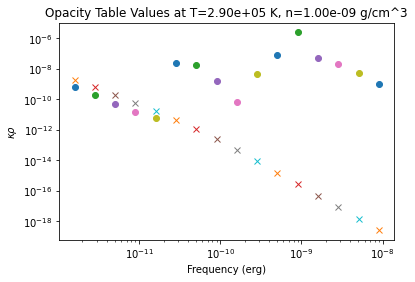

In [ ]:
frequencies = [1.0000E-03,1.7783E-03,3.1623E-03,5.6234E-03,1.0000E-02,1.7783E-02,3.1623E-02,5.6234E-02,1.0000E-01,1.7783E-01,3.1623E-01,5.6234E-01,1.0000E+00,1.7783E+00,3.1623E+00,5.6234E+00]
frequencies = np.array(frequencies)*1.602176634e-9 #convert keV to erg
tempIndex = 20
densityIndex = 72
temp = temperatures[tempIndex]* 1.602176634e-9/kB
density = densities[densityIndex]
for freqIndex in range(len(frequencies)):
    plt.plot(frequencies[freqIndex]*1e3/1.602176634e-9, density*tableValues[freqIndex,tempIndex,densityIndex], 'o')
    partA = 4*(e**6)/(3*me*c*h)
    partB = np.sqrt(2.0*np.pi/(3.0*kB*temp*me))
    gaunt_factor = 1.0
    nu = frequencies[freqIndex] / h
    coefficient = (partA*partB*(density/(0.6*mp))*(density/(0.6*mp))*(1.0 - np.exp(-h*nu/ (kB * temp)))*gaunt_factor)/(nu*nu*nu)
    plt.plot(frequencies[freqIndex]*1e3/1.602176634e-9, coefficient, 'x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (eV)')
plt.ylabel('$\\kappa \\rho$')
plt.title('Opacity Table Values at T={0:.2e} K, n={1:.2e} g/cm^3'.format(temp,density))

plt.show()


In [32]:
df = pd.read_csv('../debugOutput/opacityTableOverwritten.csv', delimiter=',')


In [33]:
print(df)

         table value  free-free value         ratio  frequency(Hz)  \
0       8.192100e-16     2.943680e-23  2.782950e+07   2.417990e+14   
1       8.192100e-16     1.991140e-23  4.114270e+07   2.792290e+14   
2       8.192100e-16     1.335980e-23  6.131920e+07   3.224390e+14   
3       8.192100e-16     8.894630e-24  9.210160e+07   3.723460e+14   
4       8.192100e-16     5.881050e-24  1.392970e+08   4.299910e+14   
...              ...              ...           ...            ...   
193595  2.119480e-23     1.037930e-21  2.042020e-02   1.177490e+18   
193596  2.119480e-23     7.520290e-22  2.818350e-02   1.359730e+18   
193597  2.119480e-23     5.422890e-22  3.908390e-02   1.570190e+18   
193598  2.119480e-23     3.889850e-22  5.448750e-02   1.813230e+18   
193599  2.119480e-23     2.773860e-22  7.640900e-02   2.093880e+18   

        temperature(K)  density(g/cm3)  
0         5.802260e+03    1.000000e-17  
1         5.802260e+03    1.000000e-17  
2         5.802260e+03    1.000000e-

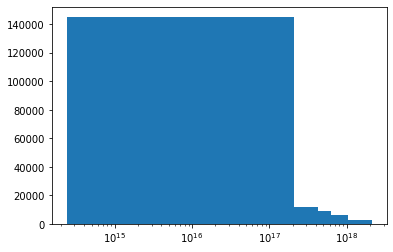

In [37]:
plt.hist(df['frequency(Hz)'])
plt.xscale('log')
plt.show()

In [39]:
np.log10(5e14)

14.698970004336019

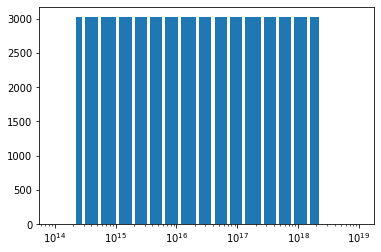

In [41]:
plt.hist(df['frequency(Hz)'], bins = np.logspace(14,19,100))
plt.xscale('log')
plt.show()

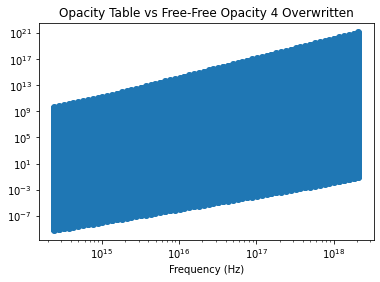

In [30]:
plt.scatter(df['frequency(Hz)'],df['ratio'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.title('Opacity Table vs Free-Free Opacity 4 Overwritten')
plt.show()

In [ ]:
df = pd.read_csv('../debugOutput/debug_opacity.csv')

In [193]:
df['temperature(K)'][25000]

'290113'

In [11]:
df = df[np.abs(df['temperature(K)']-df['temperature(K)'][25000])<=1]

In [12]:
df[np.abs(df['density(g/cm3)']-1e-12)<=1e-20]

,table value,free-free value,ratio,frequency(Hz),temperature(K),density(g/cm3)
25008,6.600200e-16,1.887820e-15,3.496200e-01,2.417990e+14,290113.0,1.000000e-12
25009,1.832100e-16,5.878320e-16,3.116710e-01,4.299910e+14,290113.0,1.000000e-12
25010,5.007200e-17,1.808980e-16,2.767970e-01,7.646410e+14,290113.0,1.000000e-12
25011,1.363800e-17,5.453690e-17,2.500690e-01,1.359730e+15,290113.0,1.000000e-12
25012,5.413900e-18,1.587270e-17,3.410830e-01,2.417990e+15,290113.0,1.000000e-12
25013,1.388800e-13,4.357770e-18,3.186950e+04,4.299910e+15,290113.0,1.000000e-12
25014,1.167500e-12,1.092730e-18,1.068420e+06,7.646410e+15,290113.0,1.000000e-12
25015,9.138100e-13,2.421910e-19,3.773100e+06,1.359730e+16,290113.0,1.000000e-12
25016,9.367700e-15,4.726390e-20,1.982000e+05,2.417990e+16,290113.0,1.000000e-12
25017,1.492300e-14,8.554390e-21,1.744480e+06,4.299910e+16,290113.0,1.000000e-12


In [13]:
df = df[np.abs(df['temperature(K)']-df['temperature(K)'][25000])<=1]
df = df[np.abs(df['density(g/cm3)']-df['density(g/cm3)'][25008])<=1e-20]
tableVals =  df['table value'].to_numpy().astype(float)
freeVals = df['free-free value'].to_numpy().astype(float)
ratio = df['ratio'].to_numpy().astype(float)
dfFreqs = df['frequency(Hz)'].to_numpy().astype(float)
dfTemps = df['temperature(K)'].to_numpy().astype(float)
dfDensities = df['density(g/cm3)'].to_numpy().astype(float)

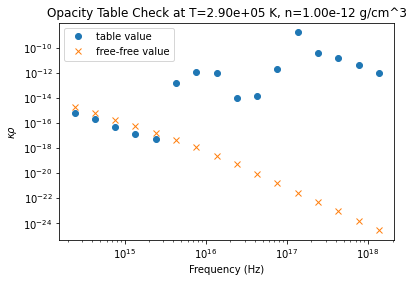

In [14]:
plt.plot(dfFreqs, tableVals, 'o', label='table value')
plt.plot(dfFreqs, freeVals, 'x', label='free-free value')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('$\\kappa \\rho$')
plt.title('Opacity Table Check at T={0:.2e} K, n={1:.2e} g/cm^3'.format(dfTemps[0],dfDensities[0]))
plt.legend()
plt.show()

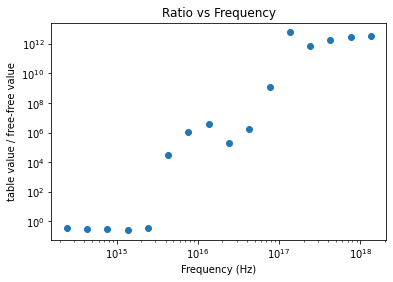

In [15]:
plt.plot(dfFreqs, ratio,'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('table value / free-free value')
plt.title('Ratio vs Frequency')
plt.show()